# 03 - Feature Selection y Aseguramiento de Calidad (Nulos)

Este notebook tiene como objetivo justificar matemáticamente cada variable que entra al modelo predictivo. Reemplazamos la eliminación manual con pruebas estadísticas formales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# 1. Cargar datos
print("Cargando datos...")
master = pd.read_parquet('../../data/interim/master_merged_v2.parquet')

# Filtramos filas sin target (Desnutrición)
master = master.dropna(subset=['HC70']).copy()
master['TARGET_DESNUTRICION'] = (master['HC70'] < -2.0).astype(int)

# Eliminamos variables de Fuga (Leakage) e identificadores que sabemos que no son predictivos
leakage_cols = [
    'HC0', 'HVIDX', 'HV112', 'HV001', 'HV002', 'HV002A', 'NCONGLOME', 'CODCCPP', 'NOMCCPP', 'ID1',
    'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12', 'HC13', 
    'HC15', 'HC16', 'HC19', 'HC30', 'HC31', 'HC32', 'HC33', 'HC71', 'HC72', 'HC73', 'HC55', 'HC70',
    'HV004', 'HV005', 'hv005', 'HV008', 'HV015', 'HV021', 'HV022', 
    'HV024', 'SHREGION', 'SHPROVIN', 'SHDISTRI', 'SHSEMES', 
    'HV120', 'HV010', 'HV035', 'HC64', 'HV114', 'HC51', 'HC60', 
    'HV218', 'HV117', 'UBIGEO', 'LONGITUDX', 'LATITUDY', 'year', 'HHID', \
    'CASEID', 'MIDX', 'BIDX', 'B16', 'extracted_HHID'
]
cols_to_drop = [c for c in leakage_cols if c in master.columns]
df_clean = master.drop(columns=cols_to_drop)

print(f"Dimensiones base: {df_clean.shape}")


Cargando datos...
Dimensiones base: (285284, 126)


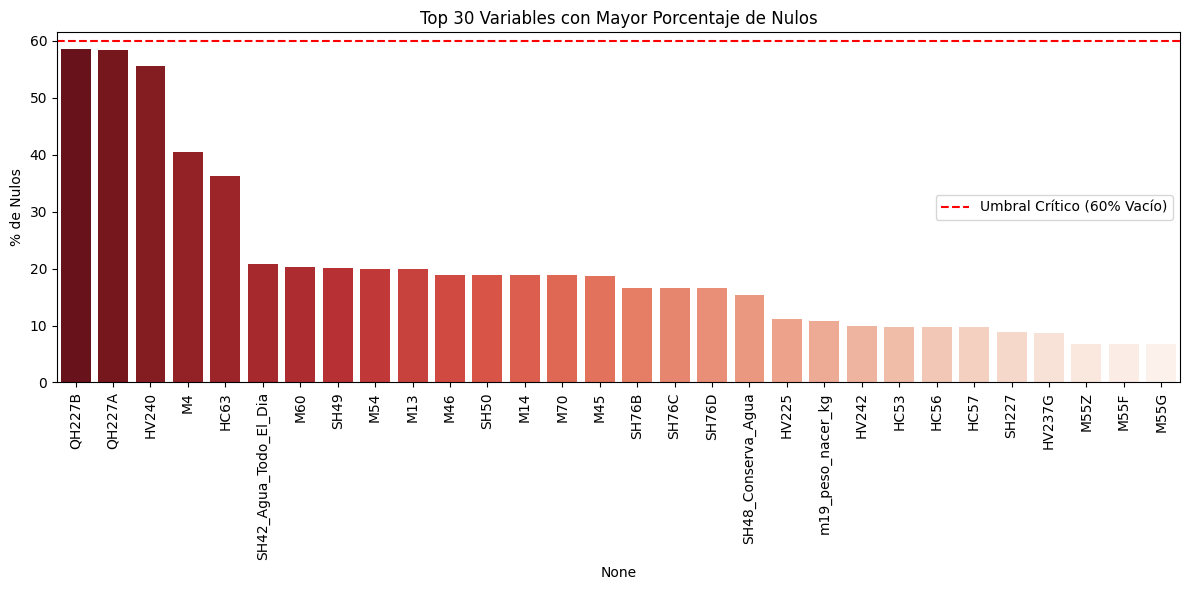

Se eliminaron 0 variables por superar el 60% de nulos.


In [2]:
# 2. AUDITORÍA VISUAL DE NULOS
# Calculamos el porcentaje de nulos por columna
null_percentages = (df_clean.isnull().sum() / len(df_clean)) * 100
null_percentages = null_percentages[null_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=null_percentages.index[:30], y=null_percentages.values[:30], palette='Reds_r')
plt.axhline(y=60, color='r', linestyle='--', label='Umbral Crítico (60% Vacío)')
plt.title('Top 30 Variables con Mayor Porcentaje de Nulos')
plt.xticks(rotation=90)
plt.ylabel('% de Nulos')
plt.legend()
plt.tight_layout()
plt.show()

# Ejecutamos la guillotina objetiva (> 60% nulos fuera)
variables_basura = null_percentages[null_percentages > 60].index.tolist()
df_clean = df_clean.drop(columns=variables_basura)
print(f"Se eliminaron {len(variables_basura)} variables por superar el 60% de nulos.")


2026-06-16 19:19:58.994 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Pares de variables altamente colineales detectados matemáticamente (>0.85):
➜ HV105 y HC1 (Correlación: 0.98)
➜ HV108 y HV106 (Correlación: 0.89)
➜ HV109 y HV106 (Correlación: 0.98)
➜ HV109 y HV108 (Correlación: 0.97)
➜ HV012 y HV009 (Correlación: 0.96)
➜ HV013 y HV009 (Correlación: 0.94)
➜ HV013 y HV012 (Correlación: 0.90)
➜ M55Z y M55G (Correlación: -0.93)


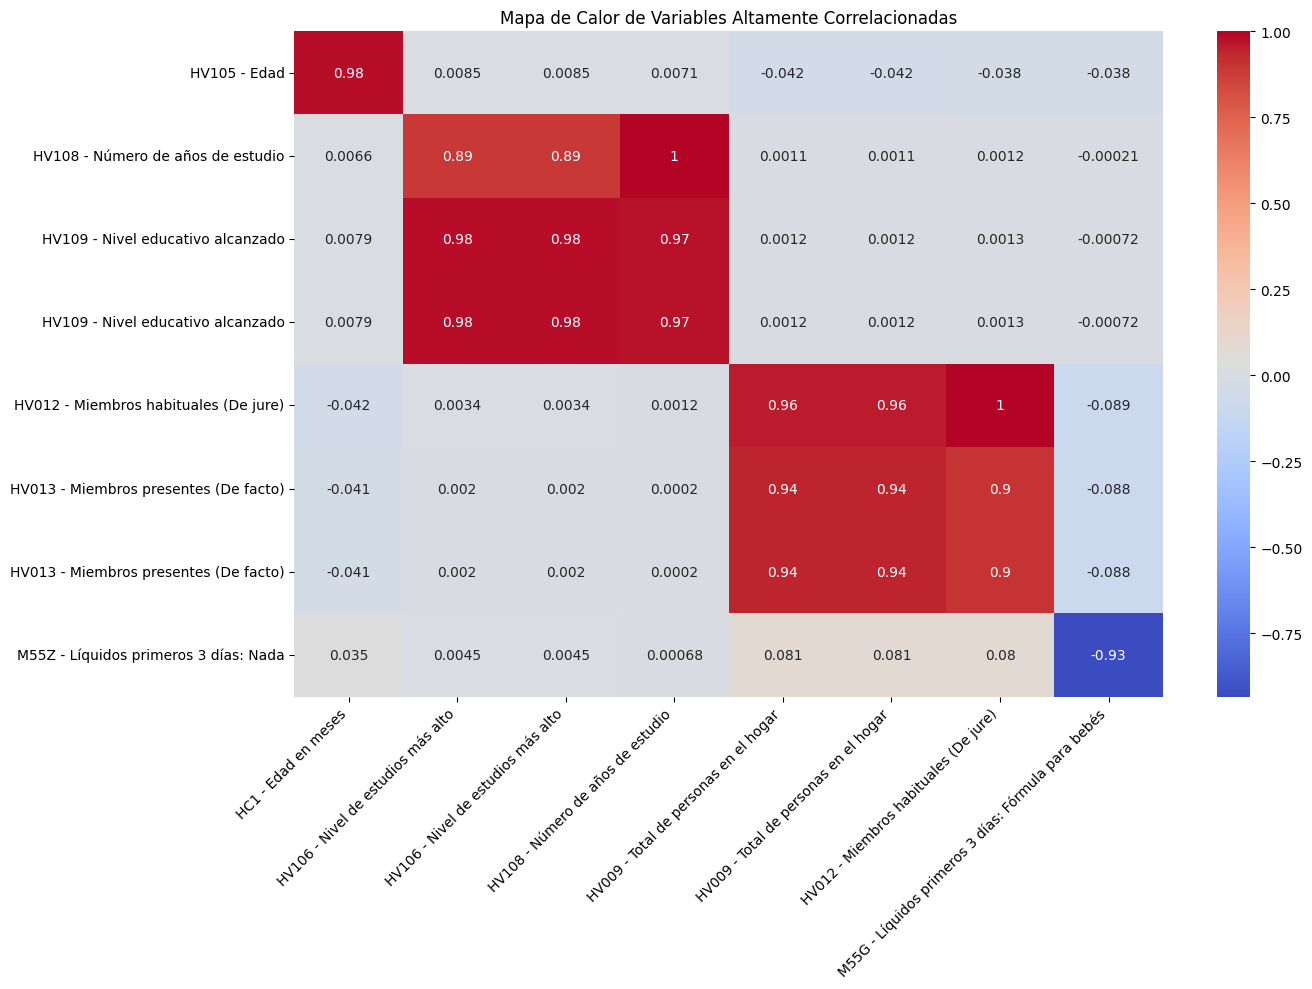

In [3]:
# 3. ANÁLISIS DE COLINEALIDAD (Correlación)
# Seleccionamos solo las numéricas para la matriz
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('TARGET_DESNUTRICION')

corr_matrix = df_clean[num_cols].corr()

# Extraer pares altamente correlacionados (> 0.85)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Pares de variables altamente colineales detectados matemáticamente (>0.85):")
for pair in high_corr_pairs:
    print(f"➜ {pair[0]} y {pair[1]} (Correlación: {pair[2]:.2f})")
    
# Visualizamos un mapa de calor simplificado con las etiquetas descriptivas
import sys
import os
sys.path.append(os.path.abspath('../../'))
try:
    from mnp.configs.column_labels import LABELS
except ImportError:
    LABELS = {}

plt.figure(figsize=(14, 10))

# Seleccionamos las columnas para el mapa
cols_y = [p[0] for p in high_corr_pairs[:10]]
cols_x = [p[1] for p in high_corr_pairs[:10]]

# Obtenemos los nombres largos del diccionario (o dejamos el corto si no existe)
labels_y = [LABELS.get(c, c) for c in cols_y]
labels_x = [LABELS.get(c, c) for c in cols_x]

# Dibujamos el mapa
ax = sns.heatmap(corr_matrix.loc[cols_y, cols_x], annot=True, cmap='coolwarm')

# Aplicamos las etiquetas legibles
ax.set_xticklabels(labels_x, rotation=45, ha='right')
ax.set_yticklabels(labels_y, rotation=0)

plt.title('Mapa de Calor de Variables Altamente Correlacionadas')
plt.tight_layout()
plt.show()

In [8]:
# 3.1 ELIMINACIÓN DE GEMELOS COLINEALES (Redundancia)
# Eliminamos las variables matemáticamente idénticas o espejos inversos perfectos
gemelos_a_eliminar = [
    'HV105', 'HV106', 'HV109', 'HV009', 'HV013', 'M55Z', # Colinealidad matemática
    'HV104', 'HC61', 'HC53', 'HC57', # Redundancias categóricas o clínicas (Ej: HC53 cruda vs HC56 ajustada)
    'HV110', 'HV121', 'HV125', 'HV126', # Educación inválida (Bebés no asisten a escuela)
    'HV206', 'HV207', 'HV208', 'HV209', 'HV210', 'HV211', 'HV212', 'HV221', # Bienes y activos absorbidos por Índice de Riqueza
    'HV243A', 'HV243C', 'HV243D', 'HV244', 'HV246', # Más activos económicos absorbidos
    'SH61A', 'SH61B', 'SH61C', 'SH61D', 'SH61E', 'SH61J', 'SH61K', 'SH61L', 'SH61M', 'SH61N', 'SH61O', 'SH61P', 'SH61Q', 'SH61R', 'SH61S', # Electrodomésticos absurdamente detallados
    'HV270' # Eliminamos el índice categórico para quedarnos con el score continuo HV271
]

cols_to_drop = [col for col in gemelos_a_eliminar if col in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"🔪 Se eliminaron {len(cols_to_drop)} columnas redundantes.")
print(f"Columnas sobrevivientes: {df_clean.shape[1]}")


🔪 Se eliminaron 37 columnas redundantes.
Columnas sobrevivientes: 83


In [9]:
# 4. PRUEBAS ESTADÍSTICAS BIVARIADAS (P-Values)
# Verificamos si cada variable tiene una relación estadísticamente significativa con la Desnutrición
from scipy.stats import chi2_contingency, kruskal

p_values = {}
features = df_clean.drop(columns=['TARGET_DESNUTRICION'])
target = df_clean['TARGET_DESNUTRICION']

for col in features.columns:
    if pd.api.types.is_numeric_dtype(features[col]):
        # Kruskal-Wallis (alternativa no paramétrica a ANOVA)
        group1 = features.loc[target == 0, col].dropna()
        group2 = features.loc[target == 1, col].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, p = kruskal(group1, group2)
            p_values[col] = p
    else:
        # Chi-Cuadrado para categóricas
        contingency = pd.crosstab(features[col], target)
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            stat, p, dof, expected = chi2_contingency(contingency)
            p_values[col] = p

p_df = pd.DataFrame(list(p_values.items()), columns=['Variable', 'P_Value'])
p_df['Relevante'] = p_df['P_Value'] < 0.05 # Rechazamos hipótesis nula

print("Prueba Estadística Bivariada Completada.")
print(f"Variables RELEVANTES (P-value < 0.05): {p_df['Relevante'].sum()}")
print(f"Variables IRRELEVANTES (P-value >= 0.05): {(~p_df['Relevante']).sum()}")

# Muestra de las irrelevantes con etiquetas descriptivas
import sys
import os
sys.path.append(os.path.abspath('../../'))
try:
    from mnp.configs.column_labels import LABELS
except ImportError:
    LABELS = {}

p_df['Descripción'] = p_df['Variable'].map(lambda x: LABELS.get(x, x))

print("\nVariables estadísticamente irrelevantes para la desnutrición:")
display(p_df[~p_df['Relevante']][['Variable', 'Descripción', 'P_Value']].head(15))

Prueba Estadística Bivariada Completada.
Variables RELEVANTES (P-value < 0.05): 71
Variables IRRELEVANTES (P-value >= 0.05): 10

Variables estadísticamente irrelevantes para la desnutrición:


,Variable,Descripción,P_Value
0,HC1,HC1 - Edad en meses,0.418598
7,HV108,HV108 - Número de años de estudio,0.112176
10,HV122,HV122 - Nivel asiste/matriculado actual,0.072578
28,HV225,HV225 - Comparte servicio higiénico,0.246274
34,HV237C,HV237C - Filtrar por paño,0.196063
36,HV237E,HV237E - Desinfección solar,1.000000
69,M55B,M55B - Líquidos primeros 3 días: Agua sola,0.452325
70,M55C,M55C - Líquidos primeros 3 días: Agua con azúcar,0.327429
72,M55F,M55F - Líquidos primeros 3 días: Jugo de fruta,0.428244
80,kpi5_lactancia_exclusiva,KPI 5 - Lactancia Materna Exclusiva,NaN


In [10]:
# 5. IMPORTANCIA MULTIVARIADA (XGBoost Feature Selection)
# Las pruebas bivariadas analizan variables de 1 en 1. XGBoost las analiza todas juntas.
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Preparamos una copia rápida convirtiendo categóricas
X_test_xgb = features.copy()
for col in X_test_xgb.columns:
    if not pd.api.types.is_numeric_dtype(X_test_xgb[col]):
        X_test_xgb[col] = X_test_xgb[col].astype(str).astype('category')

# Entrenamos un árbol rápido (sin balanceo, solo para ver poder puro)
print("Entrenando Árbol de Selección...")
xgb_selector = xgb.XGBClassifier(n_estimators=100, random_state=42, enable_categorical=True, tree_method='hist')
xgb_selector.fit(X_test_xgb, target)

# Resultados
importances = xgb_selector.feature_importances_
importance_df = pd.DataFrame({'Variable': X_test_xgb.columns, 'Importancia': importances})
importance_df = importance_df.sort_values('Importancia', ascending=False)

import sys
import os
sys.path.append(os.path.abspath('../../'))
try:
    from mnp.configs.column_labels import LABELS
except ImportError:
    LABELS = {}

basura_cols = importance_df[importance_df['Importancia'] == 0]['Variable'].tolist()

print("\nLas variables con CERO poder predictivo en conjunto (Basura algorítmica):")
for col in basura_cols:
    print(f"🗑️ {LABELS.get(col, col)}")

Entrenando Árbol de Selección...

Las variables con CERO poder predictivo en conjunto (Basura algorítmica):
🗑️ HV103 - ¿Durmió aquí anoche?
🗑️ HV124 - Años de estudio matriculado
🗑️ HV108 - Número de años de estudio
🗑️ HV237E - Desinfección solar
🗑️ HV237X - Tratamiento de agua: otros
🗑️ M55F - Líquidos primeros 3 días: Jugo de fruta
🗑️ M55E - Líquidos primeros 3 días: Solución de agua azucarada/sal
🗑️ M55I - Líquidos primeros 3 días: Miel
🗑️ KPI 5 - Lactancia Materna Exclusiva


In [11]:
# 6. EXPORTACIÓN DEL DATASET PREPROCESADO (LISTO PARA MODELADO)
print("Aplicando guillotina final a las variables basura detectadas por XGBoost...")

# Eliminamos la basura algorítmica
df_final = df_clean.drop(columns=[col for col in basura_cols if col in df_clean.columns])

print(f"Dimensiones finales para Modelado: {df_final.shape}\n")

import sys
import os
sys.path.append(os.path.abspath('../../'))
try:
    from mnp.configs.column_labels import LABELS
except ImportError:
    LABELS = {}

# Mostrar la lista de columnas finales ordenadas alfabéticamente con su descripción
columnas_finales = sorted(df_final.columns.tolist())
print("📝 LISTA DE COLUMNAS FINALES (Sobrevivientes):")
for col in columnas_finales:
    desc = LABELS.get(col, col)
    print(f"✅ {desc}")

print("\n👀 VISTAZO AL DATASET (Primeras 3 filas):")
display(df_final.head(3))

# Guardamos en la carpeta processed
output_path = '../../data/processed/master_preprocessed.parquet'
df_final.to_parquet(output_path, index=False)
print(f"\n✅ Dataset definitivo guardado exitosamente en:\n{output_path}")

Aplicando guillotina final a las variables basura detectadas por XGBoost...
Dimensiones finales para Modelado: (285284, 74)

📝 LISTA DE COLUMNAS FINALES (Sobrevivientes):
✅ HC1 - Edad en meses
✅ HC27 - Sexo
✅ HC56 - Nivel de hemoglobina ajustado por altitud
✅ HC62 - Año más alto de educación de la madre
✅ HC63 - Intervalo de nacimientos anteriores al niño
✅ HV012 - Miembros habituales (De jure)
✅ HV014 - Niños menores de 5 años
✅ HV025 - Área de residencia
✅ HV026 - Lugar de residencia
✅ HV040 - Altitud del conglomerado en metros
✅ HV101 - Parentesco con jefe de hogar
✅ HV102 - Residente habitual
✅ HV111 - ¿Está viva la madre natural?
✅ HV113 - ¿Está vivo el padre natural?
✅ HV122 - Nivel asiste/matriculado actual
✅ HV128 - Años de estudio año pasado
✅ HV201 - Fuente principal
✅ HV204 - Tiempo de viaje a fuente
✅ HV205 - Tipo de servicio higiénico
✅ HV213 - Material predominante en el piso
✅ HV214 - Material predominante en la pared
✅ HV215 - Material predominante en el techo
✅ HV216 -

,HC1,HC27,HC56,HC62,HC63,HV101,HV102,HV111,HV113,HV122,HV128,HV012,HV014,HV025,HV026,HV040,HV201,HV204,HV205,HV213,HV214,HV215,HV216,HV217,HV219,HV220,HV225,HV226,HV234,HV237,HV237A,HV237B,HV237C,HV237D,HV237F,HV237G,HV242,HV271,SHTOTH,SH49,SH50,SH63,SH71,SH76B,SH76C,SH76D,SH77F,SH227,QH227A,QH227B,SH42_Agua_Todo_El_Dia,SH48_Conserva_Agua,SH70_Fuente_Luz,HV240,M13,M14,M17,M18,M4,M45,M46,M54,M60,M70,M55A,M55B,M55C,M55G,M55H,M55X,m34_horas_inicio_lactancia,m19_peso_nacer_kg,m15_lugar_parto_agrupado,TARGET_DESNUTRICION
0,20.0,Mujer,NaN,3.0,NaN,Hijo/Hija,Sí,Sí,Sí,0.0,0.0,4.0,1.0,Urbano,Pueblo,2335.0,Red dentro de vivienda,0.0,Dentro de la vivienda,Cemento / ladrillo,Adobe o tapia,"Plancha de calamina, fibra de cemento o similares",1.0,más de 3 adultos relacionados,Masculino,26.0,Si,LPG,NaN,Si,Si,No,No,No,No,NaN,No,0.32939,1.0,NaN,NaN,NaN,1.0,Si,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,9.0,1.0,3.0,9.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.95,Institucional,1
1,28.0,Hombre,10.0,5.0,101.0,Hijo/Hija,Sí,Sí,Sí,0.0,0.0,5.0,1.0,Urbano,Pueblo,2335.0,Red dentro de vivienda,0.0,Dentro de la vivienda,Cemento / ladrillo,Adobe o tapia,"Plancha de calamina, fibra de cemento o similares",2.0,más de 3 adultos relacionados,Masculino,38.0,Si,LPG,NaN,Si,Si,No,No,No,No,NaN,Si,0.41740,1.0,NaN,NaN,NaN,2.0,No,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,9.0,0.0,3.0,17.0,1.0,18.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,3.10,Institucional,1
2,40.0,Mujer,NaN,2.0,NaN,Hijo/Hija,Sí,Sí,Sí,0.0,0.0,3.0,1.0,Urbano,Pueblo,2335.0,Red dentro de vivienda,0.0,Dentro de la vivienda,Cemento / ladrillo,Adobe o tapia,"Plancha de calamina, fibra de cemento o similares",2.0,"Dos adultos, dif. Sexo",Masculino,33.0,No,LPG,NaN,Si,Si,No,No,No,No,NaN,Si,0.86784,1.0,NaN,NaN,NaN,3.0,Si,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,6.0,0.0,3.0,18.0,1.0,30.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.60,Institucional,0



✅ Dataset definitivo guardado exitosamente en:
../../data/processed/master_preprocessed.parquet
